<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_pr_1_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock

In [ ]:
df = pd.read_csv("Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
features = ['Fresh','Milk','Grocery',
            'Frozen','Detergents_Paper',
            'Delicassen']

X = df[features]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


In [ ]:
customer1 = X_scaled[0]
customer2 = X_scaled[1]

print("Customer 1:")
print(customer1)

print("\nCustomer 2:")
print(customer2)

Customer 1:
[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]

Customer 2:
[-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]


In [ ]:
euclid_dist = euclidean(customer1, customer2)

print("Euclidean Distance =", euclid_dist)

Euclidean Distance = 0.6208578911211603


In [ ]:
manhattan_dist = cityblock(customer1, customer2)

print("Manhattan Distance =", manhattan_dist)

Manhattan Distance = 1.281254955895562


In [ ]:
cos_sim = cosine_similarity(
    customer1.reshape(1,-1),
    customer2.reshape(1,-1)
)

print("Cosine Similarity =", cos_sim[0][0])

Cosine Similarity = 0.6795783596851255


In [ ]:
similarity_matrix = cosine_similarity(X_scaled)

customer_index = 0

similarities = similarity_matrix[customer_index]

top5 = similarities.argsort()[-6:-1][::-1]

print("Top 5 Similar Customers to Customer 0:")

for idx in top5:
    print("Customer", idx,
          "Similarity =", similarities[idx])

Top 5 Similar Customers to Customer 0:
Customer 5 Similarity = 0.8213684573218397
Customer 281 Similarity = 0.7892517770622051
Customer 82 Similarity = 0.7397394347371998
Customer 94 Similarity = 0.7056613957124205
Customer 123 Similarity = 0.7039873894487316


In [ ]:
def edit_distance(str1, str2):

    m = len(str1)
    n = len(str2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1,m+1):
        for j in range(1,n+1):

            if str1[i-1] == str2[j-1]:
                dp[i][j] = dp[i-1][j-1]

            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )

    return dp[m][n]

customerA = "Customer1"
customerB = "Customer2"

print("Edit Distance =",
      edit_distance(customerA, customerB))

Edit Distance = 1


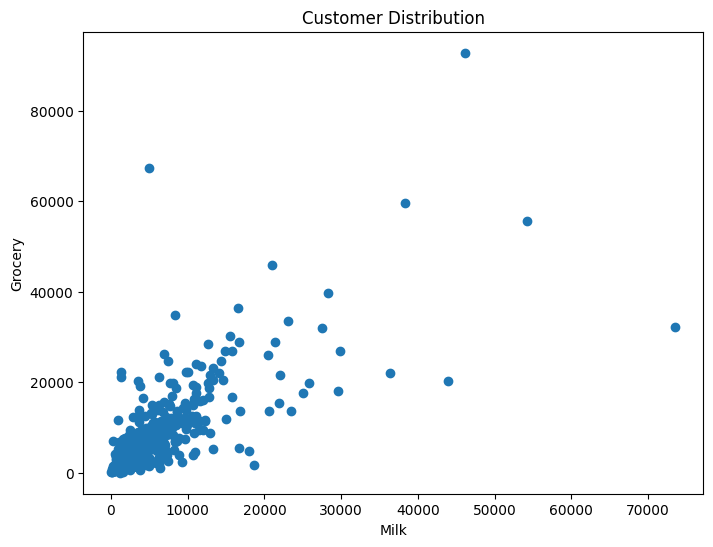

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df['Milk'], df['Grocery'])

plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("Customer Distribution")

plt.show()

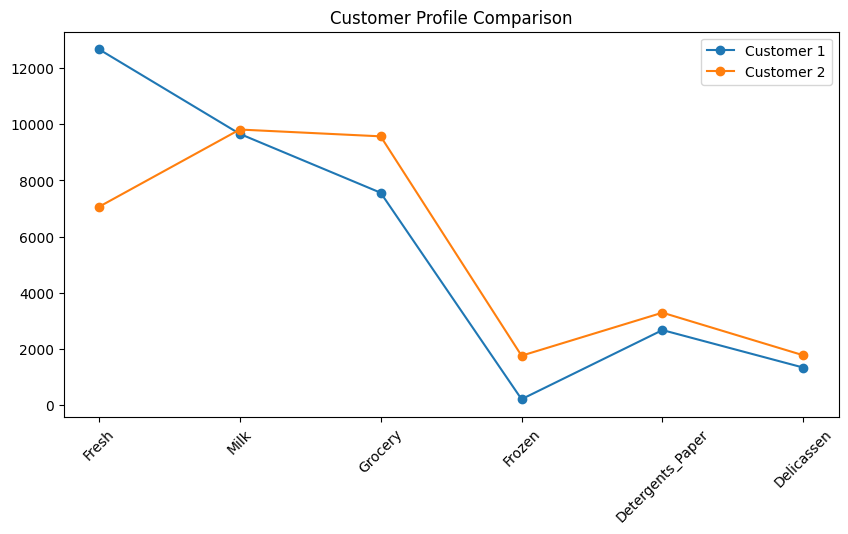

In [ ]:
customer1 = X.iloc[0]
customer2 = X.iloc[1]

labels = X.columns

x = range(len(labels))

plt.figure(figsize=(10,5))

plt.plot(x, customer1, marker='o', label='Customer 1')
plt.plot(x, customer2, marker='o', label='Customer 2')

plt.xticks(x, labels, rotation=45)

plt.title("Customer Profile Comparison")
plt.legend()

plt.show()

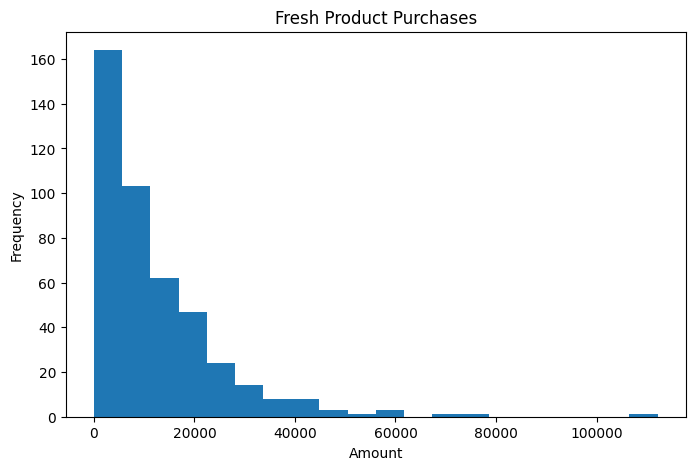

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Fresh'], bins=20)

plt.title("Fresh Product Purchases")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

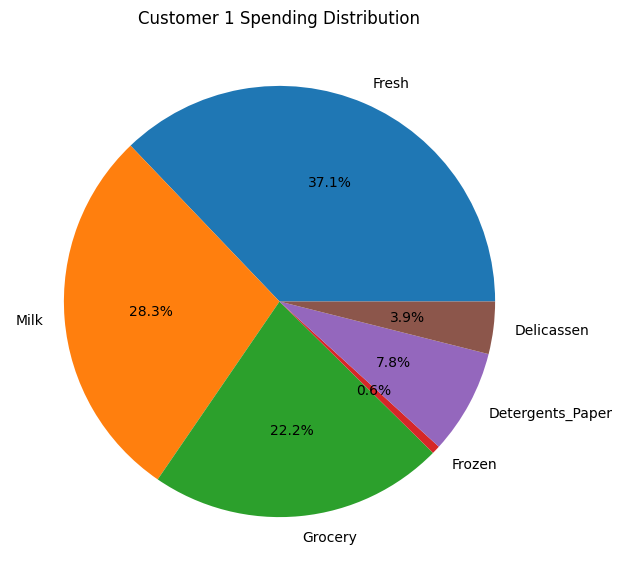

In [ ]:
customer = X.iloc[0]

plt.figure(figsize=(7,7))

plt.pie(customer,
        labels=X.columns,
        autopct='%1.1f%%')

plt.title("Customer 1 Spending Distribution")

plt.show()